# Preprocessing
**John El Berch**

> __Quick Note:__ Hi Professor Yurko, to ease the grading, I have decided to work on top of the original notebook and also split it into two new notebooks, one __EDA__ notebook and one __PREPROCESSING__ notebook. Where addressed, the Primary to-dos were highlighted __<mark>like this</mark>__. Thanks!

***
## Preliminars
### Import modules

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read the training and testing data sets
##### `train.csv` data set

In [162]:
df_train = pd.read_csv('../train.csv')
df_train.head()

,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree,formation_energy_ev_natom,bandgap_energy_ev
0,1,33,80.0,0.6250,0.3750,0.000,9.9523,8.5513,9.1775,90.0026,90.0023,90.0017,0.0680,3.4387
1,2,194,80.0,0.6250,0.3750,0.000,6.1840,6.1838,23.6287,90.0186,89.9980,120.0025,0.2490,2.9210
2,3,227,40.0,0.8125,0.1875,0.000,9.7510,5.6595,13.9630,90.9688,91.1228,30.5185,0.1821,2.7438
3,4,167,30.0,0.7500,0.0000,0.250,5.0036,5.0034,13.5318,89.9888,90.0119,120.0017,0.2172,3.3492
4,5,194,80.0,0.0000,0.6250,0.375,6.6614,6.6612,24.5813,89.9960,90.0006,119.9893,0.0505,1.3793


**<mark>Note on spacegroup:</mark>** I truly appreciate the advice given (not treating the spacegroup as a categorical first, and then verifying the assumption makes sense). The spacegroup number might be a deceiving property because, although it is an integer, it is just an index referring to the shape and geometry of the crystal at hand [More info](http://img.chem.ucl.ac.uk/sgp/misc/sgpnum.htm). I am keen on keeping this property as a categorical since it acts like an identifying index. A quick comment: although there are 230 different spacegroup numbers, there are only 7 crystal systems. In other words, there are only 7 major crystal systems (e.g., cubic, hexagonal...), each containing a subset of slightly different crystals, which can be specifically called upon via the spacegroup label. Thus, another approach to explore the data could be to create a new categorical variable identifying the main crystal system.

Create a separate, additional categorical variable for later

In [163]:
df_train['spacegroup'] = df_train['spacegroup'].astype('category')
df_train['number_of_total_atoms_cat'] = df_train['number_of_total_atoms'].astype('category')

##### *<mark>test.csv</mark>* data set

In [164]:
df_test = pd.read_csv('../test.csv')
df_test.head()

,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree
0,1,33,80.0,0.1875,0.4688,0.3438,10.5381,9.0141,9.6361,89.9997,90.0003,90.0006
1,2,33,80.0,0.7500,0.2500,0.0000,9.8938,8.5014,9.1298,90.0038,90.0023,90.0015
2,3,167,30.0,0.6667,0.1667,0.1667,4.9811,4.9808,13.4799,89.9900,90.0109,120.0014
3,4,12,80.0,0.5625,0.4375,0.0000,24.3370,6.0091,5.7620,89.9995,103.8581,90.0002
4,5,12,80.0,0.1875,0.5000,0.3125,24.6443,6.2906,6.1589,90.0000,104.5929,90.0001


In [165]:
df_test['spacegroup'] = df_test['spacegroup'].astype('category')
df_test['number_of_total_atoms_cat'] = df_test['number_of_total_atoms'].astype('category')

Create the binary number of total atoms variable

In [166]:
df_train['binary_number_of_total_atoms'] = np.where(df_train.number_of_total_atoms.to_numpy() == 80, '80', 'other')
df_test['binary_number_of_total_atoms'] = np.where(df_test.number_of_total_atoms.to_numpy() == 80, '80', 'other')

Define the corresponding variable lists:

In [167]:
## Define continous variables
output_list = ['formation_energy_ev_natom', 'bandgap_energy_ev']
categorical_list = ['spacegroup','number_of_total_atoms_cat','binary_number_of_total_atoms']
input_list = [var for var in df_train.columns if var not in output_list+categorical_list+['id']]

***
## Preliminar

You must state what types of preprocessing operations you think are important to consider for your application. Successfully answering requires that you consider:

#### Are the continuous input distributions symmetric? Do the continuous inputs have lower or upper bounds? What preprocessing operations are appropriate for such situations?
The continous inputs are not symmetrical. I believe the kind of operations to consider will ultimately depend on the type of input: 
* Percentages: The atom percentages are skewed. Based on the corrections, I will use the <mark>logit</mark> function
* Lattice vectors: The lattice vector modules depend on each material being considered. However, the proportions between lattice vectors depend on the spacegroup. I could search for more information regarding the proportions between lattice vectors for the 6 spacegroups in the dataset and compute a deviation factor (computed vs theoretical).
* Lattice angles: The angle values are defined by the spacegroup. That's why the distributions have heavy counts centered in specific values (like 90 degrees) and then few counts on other values. I believe a good approach in analyzing this data would be to compute the difference with the theoretical value and input that difference to an exponential function, so values far from the ideal are further separated from those close to the ideal. Since the only theoretical values available for all the spacegroups are the gamma and alpha angles, I will compute the deviations for these two values. Also, since using the exponential function resulted in some very large or small values, I will use the sigmoid function centered around zero:

$$ S(x) = \frac{\exp{ \left( \alpha - \alpha_{theory} \right)}}{1+exp{ \left( \alpha - \alpha_{theory} \right)}} - \frac{1}{2} $$

> **NOTE:** <mark>Following the corrections</mark>, I will standarize the features derived from lattice angle variables (the final features)

#### Are the categorical inputs balanced, or are low frequency categories present?
Spacegroup categorical is balanced, but the number of atoms isn't.

#### What is the correlation structure between the continuous inputs?
The angles, as well as the lattice vector modules, seem to be related to each other (as expected, since their relative values depend on the spacegroup). Of interest is the linear correlation between lattice angles alpha and beta for spacegroup 227, which, opposed to a cluster of points centered on fixed values, spawns an array of values.

#### Are there obvious relationships between the categorical inputs?
There are. Certain spacegroups have only a fixed number of atoms. For instance, spacegroup 227 samples have all 40 atoms. Similarly, spacegroup 167 samples have 30 or 60 atoms. On the other hand, smaller crystal units containing 10 or 20 atoms only have one spacegroup associated.

#### Did the EDA reveal that you should consider interactions between variables?
Interactions between categoricals and continous variables seem to be fit.

#### Did the EDA reveal that you should consider non-linear relationships between the output and continuous inputs?
Yes, particularly, for the bandgap energy and formation energies as function of the percentage of atoms Al and In.

#### Do you feel the OUTPUT needs transformed/preprocessed in some way?
<mark> Based on the corrections </mark> I do believe I need to take the log of the bandgap output since it should be a value greater or equal to zero. For this case, since we are interested in semiconductors, the bandgap should always be greater than zero. The formation energy might be negative for some cases, hence, I won't apply the log correction to the output.

***
## Manually execute the actions by creating new variables within DataFrames

### Create new variables
<u><mark>New</mark> Variable 1: Deviations from ideal spacegroup data</u>

Build a dictionary with the theoretical angles and lattice proportions for each spacegroup. I will use `None` for crystals that have no defined proportion on angles or lattice vector lengths. I took the information from [Wikipedia](https://en.wikipedia.
org/wiki/Main_Page) and [MaterialsProject](https://materialsproject.org/)

<mark>NOTE:</mark> I will use the merge alternative, but leave the dictionary as a reference

In [168]:
#Dictionary {'spacegroup' : [alpha, beta, gamma, a/b, a/c]}
spacegroup_dictio = {'206' : [90, 90, 90, 1, 1],
                     '33' : [90, 90, 90, None, None],
                     '227' : [90, 90, 90, 1, 1],
                     '167' : [90, 90, 120, 1, None],
                     '12' : [90, None, 90, None, None, None],
                     '194' : [90, 90, 120, 1, None]}

Spacegroup_df = pd.DataFrame({'alpha_theory' : [90, 90, 90, 90, 90, 90],
                             'gamma_theory' : [90, 90, 90, 120, 90, 120] , 
                            'spacegroup' : [206, 33, 227, 167, 12, 194]})

In [169]:
prepro_df_train = pd.merge(left=Spacegroup_df,right=df_train, how='inner', on='spacegroup')
prepro_df_test = pd.merge(left=Spacegroup_df,right=df_test, how='inner', on='spacegroup')

Create a new intermediate feature comparing the predicted and theoretical values

In [170]:
prepro_df_train['alpha_comparisson'] = prepro_df_train['lattice_angle_alpha_degree'] - prepro_df_train['alpha_theory']
prepro_df_train['gamma_comparisson'] = prepro_df_train['lattice_angle_gamma_degree'] - prepro_df_train['gamma_theory']

In [171]:
prepro_df_test['alpha_comparisson'] = prepro_df_test['lattice_angle_alpha_degree'] - prepro_df_test['alpha_theory']
prepro_df_test['gamma_comparisson'] = prepro_df_test['lattice_angle_gamma_degree'] - prepro_df_test['gamma_theory']

Create sigmoid feature

In [172]:
def sigmoid(x):
    return np.exp(x) / (np.exp(x)+1) - 0.5

In [173]:
prepro_df_train['alpha_sigmoid'] = sigmoid(prepro_df_train['alpha_comparisson'])
prepro_df_train['gamma_sigmoid'] = sigmoid(prepro_df_train['gamma_comparisson'])
prepro_df_test['alpha_sigmoid'] = sigmoid(prepro_df_test['alpha_comparisson'])
prepro_df_test['gamma_sigmoid'] = sigmoid(prepro_df_test['gamma_comparisson'])


<u>Variable 2: Proportions between lattice constants</u>

In [174]:
prepro_df_train['a_to_b'] = prepro_df_train.lattice_vector_1_ang.to_numpy() / prepro_df_train.lattice_vector_2_ang.to_numpy()
prepro_df_test['a_to_b'] = prepro_df_test.lattice_vector_1_ang.to_numpy() / prepro_df_test.lattice_vector_2_ang.to_numpy()

In [175]:
prepro_df_train['a_to_c'] = prepro_df_train.lattice_vector_1_ang.to_numpy() / prepro_df_train.lattice_vector_3_ang.to_numpy()
prepro_df_test['a_to_c'] = prepro_df_test.lattice_vector_1_ang.to_numpy() / prepro_df_test.lattice_vector_3_ang.to_numpy()

<u><mark>New</mark> Variable 3: Logit transformation of percentages</u>

In [176]:
'percent_atom_'

for element in ['al','ga','in']:
    for df in [prepro_df_test, prepro_df_train]:
        P = (df['percent_atom_'+element].to_numpy() - -0.01) / (1.02)
        OR = P / (1-P)
        df['logit_'+element] = np.log(OR)

<u><mark>New</mark> Variable 4: Log transformation of Bandgap energy</u>

In [177]:
prepro_df_train['log_bandgap'] = np.log(prepro_df_train.bandgap_energy_ev.to_numpy())

***
##  Apply preprocessing operations with sklearn functions, and using the formula interface with dmatrices() to generate the features

In [178]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from patsy import dmatrices

Create an updated input list with all the new transformed features

In [179]:
input_list = ['number_of_total_atoms', 'logit_al', 'logit_ga', 'logit_in', 'a_to_b', 'a_to_c', 'alpha_sigmoid', 'gamma_sigmoid', 'lattice_vector_1_ang', 'lattice_vector_2_ang', 'lattice_vector_3_ang']

Create 2 input lists, one with treating the number of atoms as a categorical and another one treating it as a categorical. This ensures considering certain variables as categoricals and as continous, in accordance with the suggestions

In [180]:
# Will use dictionaries to ease accessing the info. The structure is {'key' : [[continous],[categorical]}
Input_list_cases = {'natoms_continous' : [input_list.copy() , ['spacegroup']],
                    'natoms_categorical' : [[inp for inp in input_list if inp != 'number_of_total_atoms'] , [inp for inp in categorical_list if inp != 'binary_number_of_total_atoms']],
                    'natoms_binary' : [[inp for inp in input_list if inp != 'number_of_total_atoms'] , [inp for inp in categorical_list if inp != 'number_of_total_atoms_cat']]}

output_list = ['formation_energy_ev_natom','log_bandgap']

### Generate the features with the formula interface

Define helping functions for <mark>each model</mark>
* Additive all features
* Additive with interactions continous/categorical
* Binary interactions between continous variables, additive interactions continous/categorical, and second power of continous variables

In [181]:
def AdditiveModel(continous,categorical,output,df):
    f = f"{output} ~ {' + '.join(continous)} + {' + '.join(categorical)}"
    y,X = dmatrices(f, data=df)
    return(y.ravel(),X)

In [182]:
def CategoricalContinousInteraction(continous,categorical,output,df):
    f = f"{output} ~ ({' + '.join(continous)}) * ({' + '.join(categorical)})"
    y,X = dmatrices(f, data=df)
    return(y.ravel(),X)

In [183]:
def BinaryInteractionContinous(continous,categorical,output,df):
    f = f"{output} ~ {' + '.join([f'np.power({var},2)' for var in continous])} + ({' + '.join(continous)})**2 + {' + '.join(categorical)}"
    y,X = dmatrices(f, data=df)
    return(y.ravel(),X)

Generate the models and store them in a dictionary 

In [184]:
# Start an empty dictionary. The ultimate structure will be
# {'Name_of_model' : [y,X]}
Models = {}

# Iterate for the two identified outputs of interest
for output in output_list:
    # Iterate for the 3 input list cases
    for input in list(Input_list_cases.keys()):
        key_base = f'{output}_with_{input}'
        Models['ADD_'+key_base] = AdditiveModel(Input_list_cases[input][0],Input_list_cases[input][1],output,prepro_df_train)
        Models['POLY_'+key_base] = BinaryInteractionContinous(Input_list_cases[input][0],Input_list_cases[input][1],output,prepro_df_train) 
        Models['INT_'+key_base] = CategoricalContinousInteraction(Input_list_cases[input][0],Input_list_cases[input][1],output,prepro_df_train)

In [185]:
## Let's take a glimpse of all the generated models
[' '.join(car.split('_')) for car in list(Models.keys())]

['ADD formation energy ev natom with natoms continous',
 'POLY formation energy ev natom with natoms continous',
 'INT formation energy ev natom with natoms continous',
 'ADD formation energy ev natom with natoms categorical',
 'POLY formation energy ev natom with natoms categorical',
 'INT formation energy ev natom with natoms categorical',
 'ADD formation energy ev natom with natoms binary',
 'POLY formation energy ev natom with natoms binary',
 'INT formation energy ev natom with natoms binary',
 'ADD log bandgap with natoms continous',
 'POLY log bandgap with natoms continous',
 'INT log bandgap with natoms continous',
 'ADD log bandgap with natoms categorical',
 'POLY log bandgap with natoms categorical',
 'INT log bandgap with natoms categorical',
 'ADD log bandgap with natoms binary',
 'POLY log bandgap with natoms binary',
 'INT log bandgap with natoms binary']

### Apply `StandardScaler` to select variables

In [186]:
# Streamline the process and store the Xstan in a new dictionary
# {'Name_of_model' : df_stan}
Models_Stan = {}

for key in list(Models.keys()):
    y = Models[key][0]
    X = Models[key][1]

    # Filter the variables to standarize (the continous variables)
    normalize = [var for var in Models[key][1].design_info.column_names
    if any(cat_string in var for cat_string in categorical_list+['Intercept']) is False]

    # Keep the categoricals for later
    categoricals = [var for var in categorical_list
                    if any(var in string for string in Models[key][1].design_info.column_names) is True]

    # Standarize the variables, I will convert it to a dataframe here so I can filter the continous variables
    XStan = StandardScaler().fit_transform(pd.DataFrame(X, columns=X.design_info.column_names).loc[:,normalize], y)

    # Create a new data frame to make the join with the categoricals
    Stan_df = pd.DataFrame(XStan, columns = normalize)

    # Create dummy variables of the categoricals
    Cat_df = pd.get_dummies(prepro_df_train.loc[:,categoricals], columns=categoricals, drop_first = True)

    # # Join the categoricals
    # Stan_df = pd.concat([Stan_df,
    #                     prepro_df_train.loc[:,categoricals]],
    #                     axis=1)

    # Join the categorical dummies
    Stan_df = pd.concat([Stan_df,
                        Cat_df],
                        axis=1)
    
    # Store the new DataFrame into the new dictionary
    Models_Stan[key] = Stan_df

c:\Users\joe48\Anaconda3\envs\cmpinf\lib\site-packages\pandas\core\algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)
c:\Users\joe48\Anaconda3\envs\cmpinf\lib\site-packages\pandas\core\algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)
c:\Users\joe48\Anaconda3\envs\cmpinf\lib\site-packages\pandas\core\algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)
c:\Users\joe48\Anaconda3\envs\cmpinf\lib\site-packages\pandas\core\algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (m

Visualize the continous variables via box plot for one case

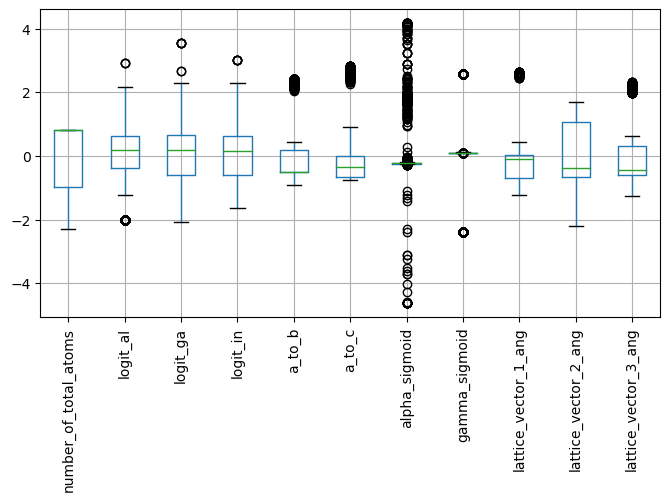

In [187]:
fig,ax = plt.subplots(figsize=(8,4))
Models_Stan['ADD_formation_energy_ev_natom_with_natoms_continous'].loc[:,input_list].boxplot(ax=ax)
ax.tick_params(axis='x', which='both', labelrotation=90)
plt.show()

***
## Create as much of the preprocessing actions as necessary within Pipelines

In [188]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures

In [189]:
num_transform = Pipeline(steps = [ ('interactions', PolynomialFeatures(degree=2)),
                                  ('std_input', StandardScaler()) ])
cat_transform = Pipeline(steps = [ ('dummy', OneHotEncoder(drop='first')) ])

In [190]:
## Store the preprocessed dataframes on a dictionary
# {'Name_of_model' : df_stan}
Prepro_Stan = {}

for key in list(Input_list_cases.keys()):
    continous = Input_list_cases[key][0]
    categorical = Input_list_cases[key][1]

    comp_transform = ColumnTransformer( transformers = [ ('num', num_transform, continous),
                                                        ('cat', cat_transform, categorical)],
                                                        remainder = 'drop')

    auto_prepro_df = pd.DataFrame(comp_transform.fit_transform(prepro_df_train.loc[:,continous+categorical]),
                                  columns=comp_transform.fit(prepro_df_train.loc[:,continous+categorical]).get_feature_names_out())


    Prepro_Stan[key] = auto_prepro_df

In [191]:
Prepro_Stan['natoms_continous']

,num__1,num__number_of_total_atoms,num__logit_al,num__logit_ga,num__logit_in,num__a_to_b,num__a_to_c,num__alpha_sigmoid,num__gamma_sigmoid,num__lattice_vector_1_ang,...,num__lattice_vector_1_ang lattice_vector_2_ang,num__lattice_vector_1_ang lattice_vector_3_ang,num__lattice_vector_2_ang^2,num__lattice_vector_2_ang lattice_vector_3_ang,num__lattice_vector_3_ang^2,cat__spacegroup_33,cat__spacegroup_167,cat__spacegroup_194,cat__spacegroup_206,cat__spacegroup_227
0,0.0,0.810885,-1.236432,-0.591806,1.645385,-0.510024,-0.091632,-0.233809,0.104084,0.024165,...,0.829897,-0.159033,1.819442,0.480285,-0.495109,0.0,0.0,0.0,1.0,0.0
1,0.0,0.810885,0.527417,-0.021637,0.158897,-0.509983,-0.091595,-0.230288,0.102966,-0.111140,...,0.447659,-0.574947,1.270493,0.051484,-0.582279,0.0,0.0,0.0,1.0,0.0
2,0.0,0.810885,-0.546214,1.877382,-1.624358,-0.510014,-0.091557,-0.222805,0.097374,-0.120247,...,0.423083,-0.601870,1.235311,0.023814,-0.587942,0.0,0.0,0.0,1.0,0.0
3,0.0,0.810885,1.226495,-1.194256,-0.124949,-0.509951,-0.091585,-0.231389,0.104581,-0.146734,...,0.352019,-0.678962,1.133077,-0.055804,-0.604078,0.0,0.0,0.0,1.0,0.0
4,0.0,0.810885,-2.012235,0.883170,0.574849,-0.510024,-0.091596,-0.228307,0.100108,-0.042238,...,0.638626,-0.367264,1.544819,0.265656,-0.538763,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,0.0,0.810885,0.953522,-1.194256,0.158897,-0.509963,-0.753191,-0.207840,0.104332,-0.653547,...,-0.784783,1.178327,-0.498979,1.858463,2.226615,0.0,0.0,1.0,0.0,0.0
2396,0.0,-2.287334,2.935729,-2.074842,-1.624358,-0.509961,-0.758045,-0.226547,0.114272,-1.238954,...,-1.577084,-2.048320,-1.636478,-1.467119,-0.303237,0.0,0.0,1.0,0.0,0.0
2397,0.0,0.810885,0.800997,0.348213,-1.624358,-0.509993,-0.756771,-0.195517,0.109178,-0.683082,...,-0.838099,1.020434,-0.575480,1.695857,2.150656,0.0,0.0,1.0,0.0,0.0
2398,0.0,0.810885,0.593798,0.583397,-1.624358,-0.510008,-0.756384,-0.194196,0.107811,-0.678015,...,-0.829031,1.051368,-0.562439,1.727809,2.170060,0.0,0.0,1.0,0.0,0.0


### Checks
After executing the preprocessing approaches, check if the number of features created by the manual + dmatrices() approach is consistent with the Pipelines approach. If the number of features are different, why do you think that is the case?

I will check only the manual polynomial features case, which is the same in both applications

In [192]:
N_Features_Manual = []
N_Features_Prepro = []

for key in [Poly_key for Poly_key in list(Models_Stan.keys()) if 'POLY' in Poly_key][0:3]:
    N_Features_Manual.append(Models_Stan[key].shape[1])

for key in Prepro_Stan.keys():
    N_Features_Prepro.append(Prepro_Stan[key].shape[1])

In [193]:
N_Features_Manual

[82, 75, 71]

In [194]:
N_Features_Prepro

[83, 76, 72]

The lengths are the same, considering that sklearn doesn't discard the first column

***
## Explore generated preprocessed features
> **NOTE:** I will use the features generated manually

### How many features are present? How do the number of features compare to the original number of inputs?

In [195]:
N_Features_Manual = []
for key in [Poly_key for Poly_key in list(Models_Stan.keys()) if 'POLY' in Poly_key][0:3]:
    N_Features_Manual.append(Models_Stan[key].shape[1])

Original_Number_of_Inputs = df_train.shape[0]

In [196]:
print(f'The max number of features for any of the considered models is {max(N_Features_Manual)}, which is lower than the original number of observations equal to {Original_Number_of_Inputs}')

print(f'The original number of inputs was {pd.read_csv("../train.csv").shape[1]-2}, lower than the new number')

The max number of features for any of the considered models is 82, which is lower than the original number of observations equal to 2400
The original number of inputs was 12, lower than the new number


### Visualize the distributions associated with the features. Are the distributional shapes what you expected based on your selected preprocessing actions?

<u>Distribution of the sigmoid function values for the differences between predicted and theoretical values for angles alpha and gamma</u>

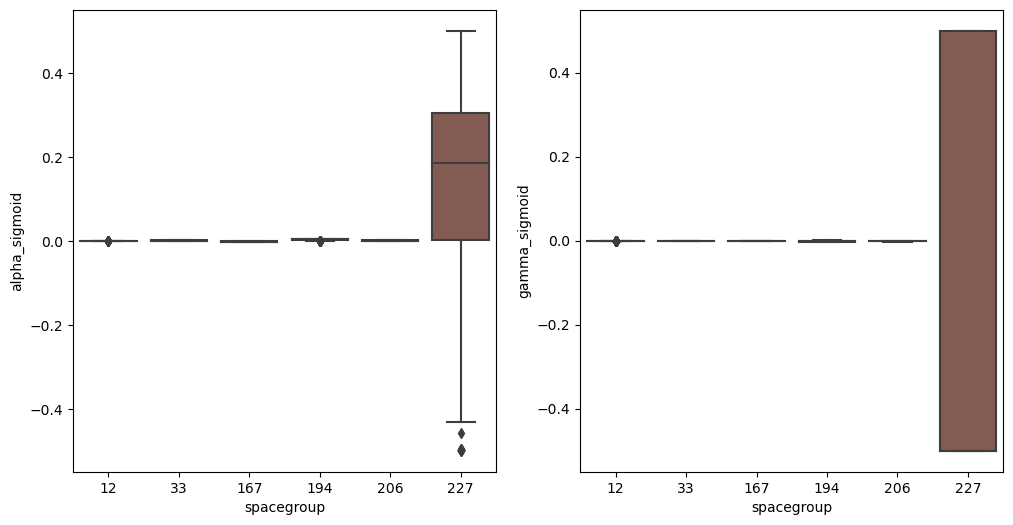

In [197]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
sns.boxplot(data=prepro_df_train, x='spacegroup', y='alpha_sigmoid', ax=ax[0])
sns.boxplot(data=prepro_df_train, x='spacegroup', y='gamma_sigmoid', ax=ax[1])
plt.show()

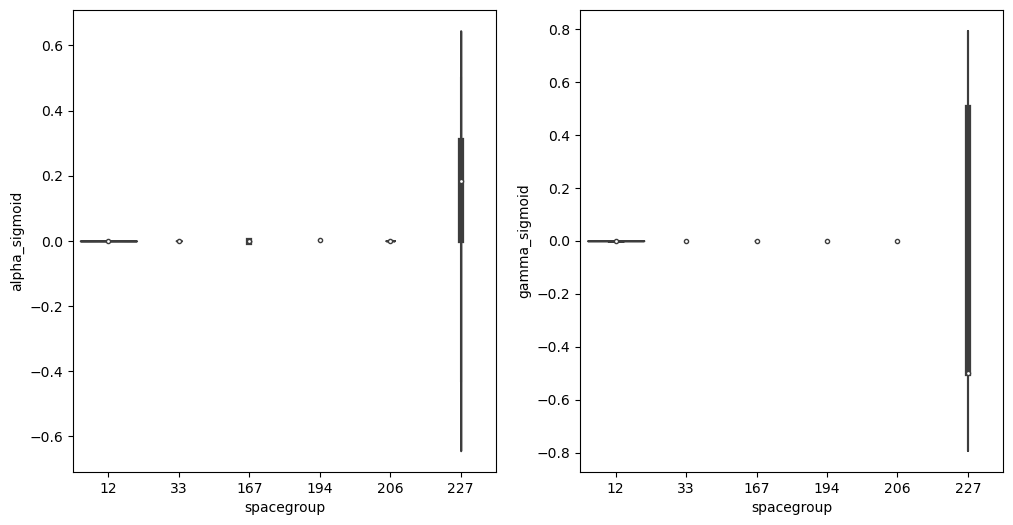

In [198]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
sns.violinplot(data=prepro_df_train, x='spacegroup', y='alpha_sigmoid', ax=ax[0])
sns.violinplot(data=prepro_df_train, x='spacegroup', y='gamma_sigmoid', ax=ax[1])
plt.show()

In general, the sigmoid values are concentrated around zero (small differences between predicted and theoretical values), except for the spacegroup 227, where more deviations appear to be present

<u>Proportions between lattice vector lengths</u>

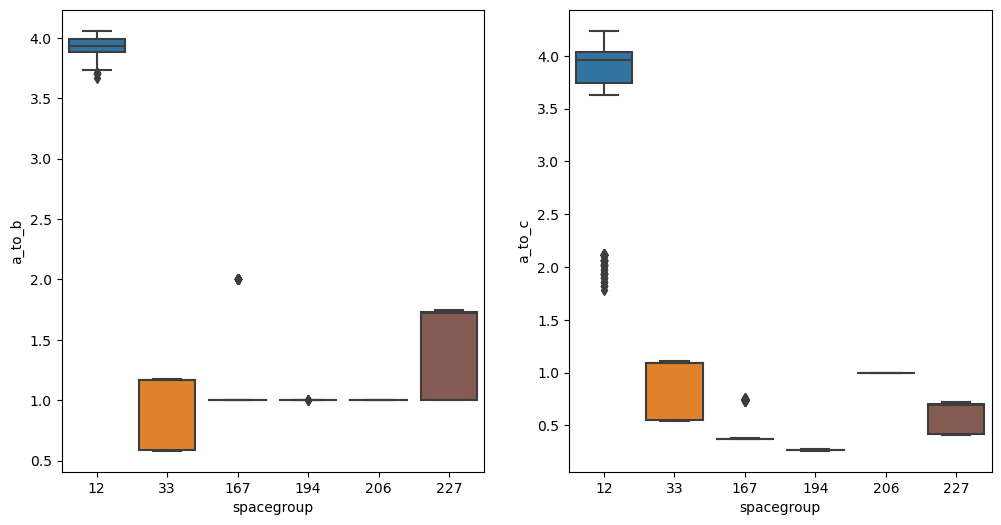

In [199]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
sns.boxplot(data=prepro_df_train, x='spacegroup', y='a_to_b', ax=ax[0])
sns.boxplot(data=prepro_df_train, x='spacegroup', y='a_to_c', ax=ax[1])
plt.show()

In general, the ratios seem to be centered around certain values, which is no surprise given that some of them have proportions fixed by their spacegroups

<u>Sigmoid for the percentages</u>

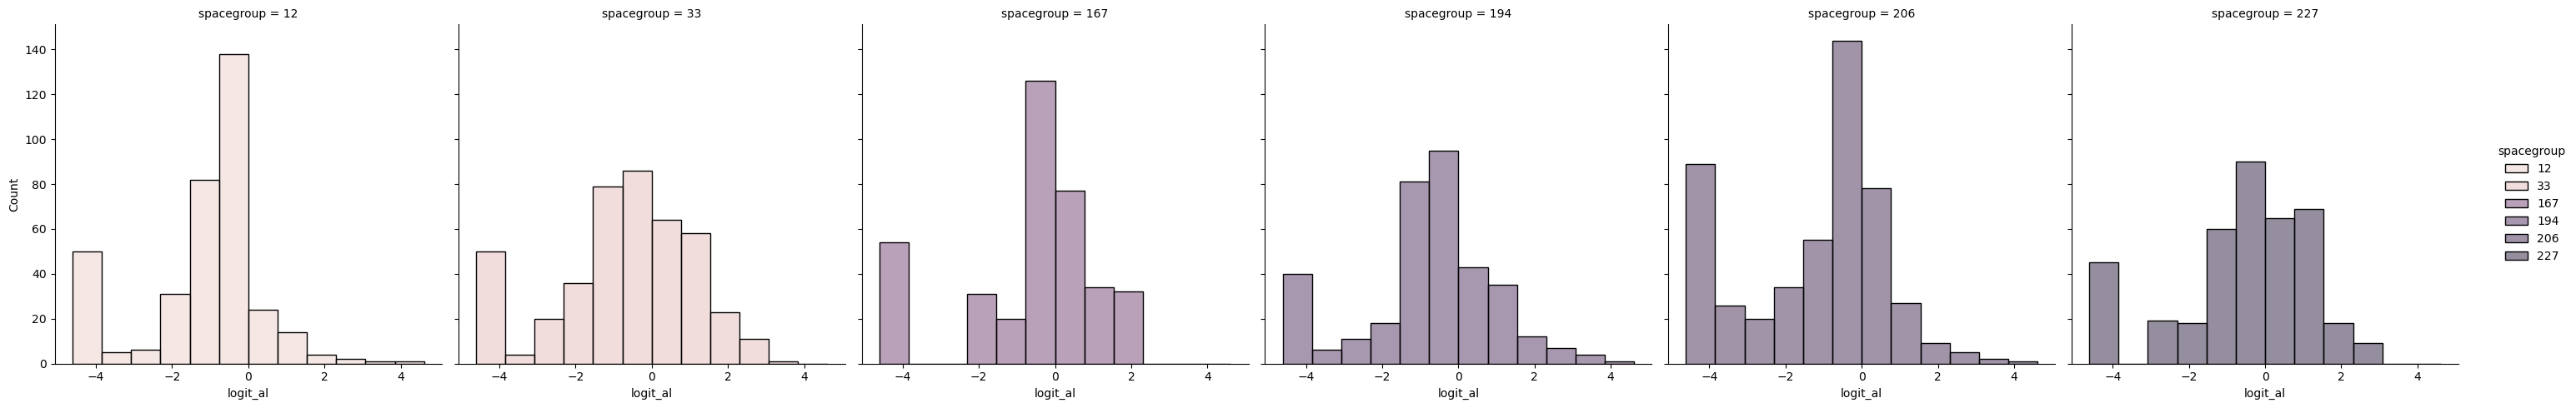

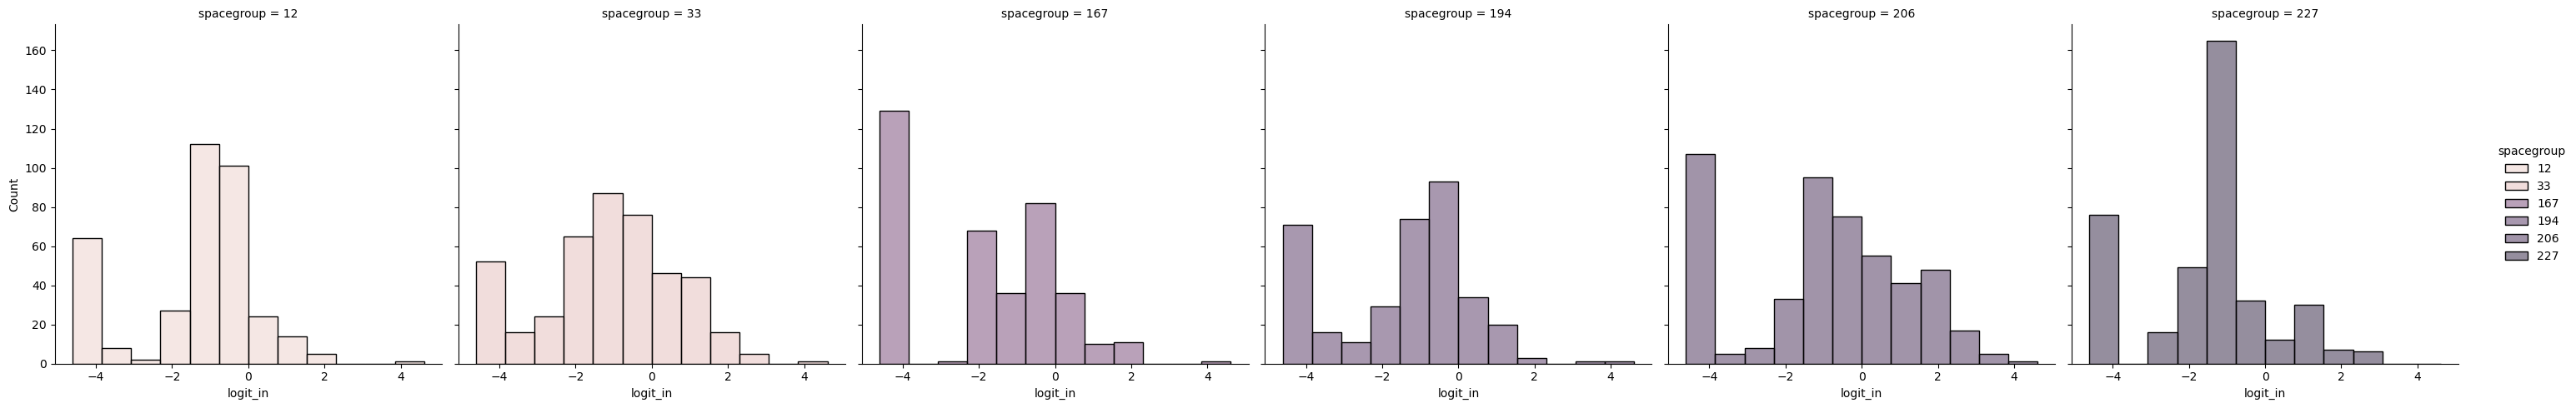

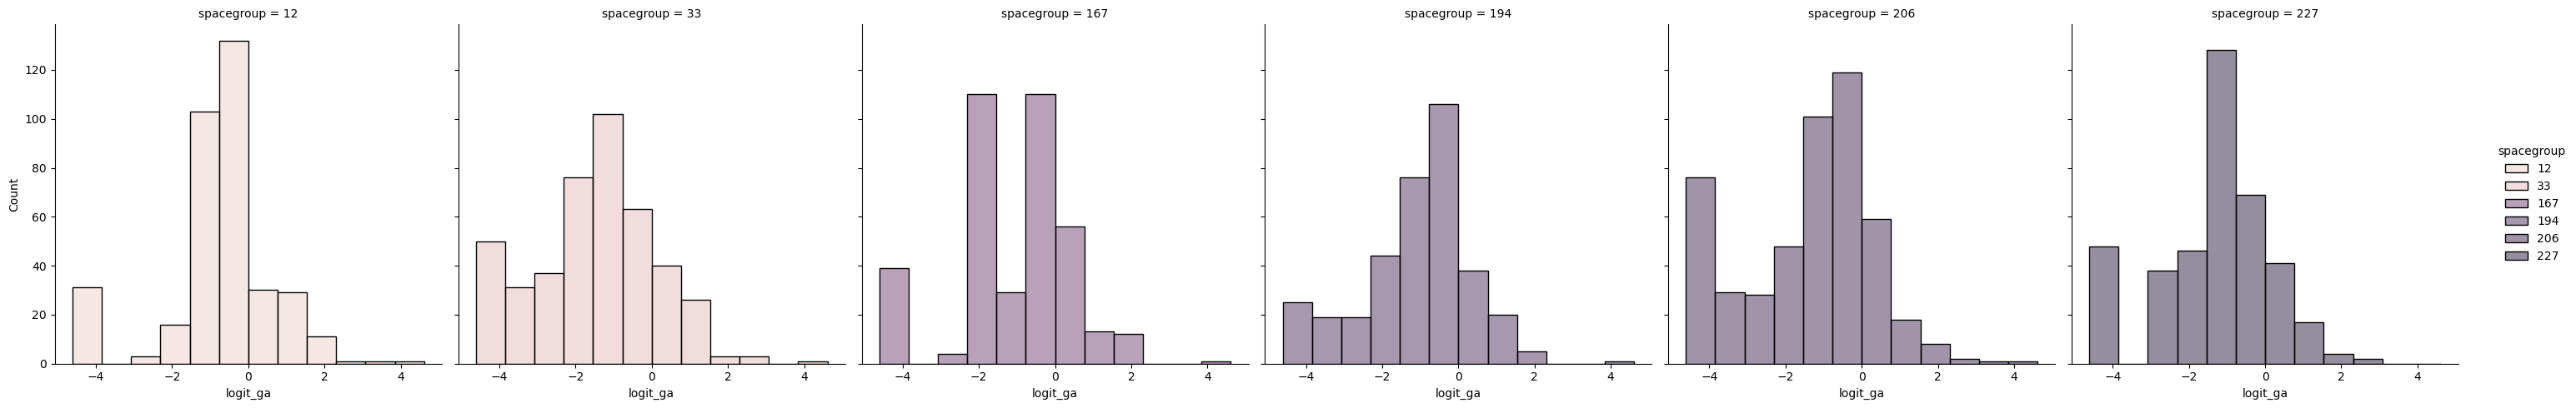

In [200]:
sns.displot(data=prepro_df_train, x='logit_al', hue='spacegroup', col='spacegroup', bins=12)
sns.displot(data=prepro_df_train, x='logit_in', hue='spacegroup', col='spacegroup', bins=12)
sns.displot(data=prepro_df_train, x='logit_ga', hue='spacegroup', col='spacegroup', bins=12)
plt.show()

The percentages seem to be less skewed than the original case

#### Do the preprocessed features cover similar ranges/scales or are the preprocessed features different ranges/scales?

They cover different ranges, as they were centered around zero